## WandB

In [1]:
import wandb
import pandas as pd
wandb.login()

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: francesca-drummer. Use `wandb login --relogin` to force relogin


In [2]:
Legnini_GNN_crossgene_experiment = "ph9oavs9"
Legnini_GNNTrans_crossgene_experiment = "32e8lneu"

In [27]:
def load_result_as_df(sweep_id):
    """
    sweep_id: str - ID from WandB run
    """
    api = wandb.Api()
    entity, project = "francesca-drummer", "InterScale_hyperparameter_sweep"  

    # Get all runs associated with the sweep
    sweep_runs = api.sweep(f"{entity}/{project}/{sweep_id}").runs

    data = []
    for run in sweep_runs:
        run_data = {
            "id": run.id,
            "name": run.name,
            "seed": run.config.get("model.optim.seed", None),
            "state": run.state,  # finished, running, failed
            "pct_mask_nodes": run.config.get("dataset.pct_mask_nodes", None),
            "radius": run.config.get("dataset.spatial_neigbors_kwargs.radius", None),
            "decoder_type": run.config.get("model.decoder.type", None),
            "test_r2": run.summary.get("test_r2", None),
            "test_pearson_corr": run.summary.get("test_pearson_corr", None),
            "runtime_seconds": run.summary.get("_runtime", None),
        }
        data.append(run_data)
        
    # Convert to DataFrame
    df = pd.DataFrame(data)
    
    return df

In [41]:
def compute_mean_and_std(df):
    # Compute mean and standard deviation
    df_agg = df.groupby(["pct_mask_nodes", "radius", "decoder_type"]).agg(
        mean_test_r2=("test_r2", "mean"),
        std_test_r2=("test_r2", "std"),
        mean_test_pearson=("test_pearson_corr", "mean"),
        std_test_pearson=("test_pearson_corr", "std"),
        mean_run_time=("runtime_seconds", "mean"),
        std_run_time=("runtime_seconds", "std"),
    ).reset_index()

    return df_agg

In [67]:
df_gnn = load_result_as_df(Legnini_GNN_crossgene_experiment)
df_agg_gnn = compute_mean_and_std(df_gnn)
df_agg_gnn.head()

,pct_mask_nodes,radius,decoder_type,mean_test_r2,std_test_r2,mean_test_pearson,std_test_pearson,mean_run_time,std_run_time
0,0.0,0,linear,0.215774,0.428353,0.463107,0.405967,248.121250,191.150328
1,0.0,0,nonlinear,0.384891,0.373139,0.632855,0.318335,304.415826,146.998133
2,0.0,100,linear,0.200444,0.468355,0.425370,0.454796,248.669297,190.998759
3,0.0,100,nonlinear,0.386292,0.384239,0.596542,0.405699,332.892815,167.689622
4,0.0,200,linear,0.355759,0.372503,0.588741,0.360033,330.627940,178.721700


In [68]:
df_gnntrans = load_result_as_df(Legnini_GNNTrans_crossgene_experiment)
df_agg_gnntrans = compute_mean_and_std(df_gnntrans)
df_agg_gnntrans.head()

,pct_mask_nodes,radius,decoder_type,mean_test_r2,std_test_r2,mean_test_pearson,std_test_pearson,mean_run_time,std_run_time
0,0.0,0,linear,0.699093,0.046392,0.861675,0.021734,786.298800,84.134047
1,0.0,0,nonlinear,0.654882,0.096546,0.839183,0.031326,820.913805,259.135376
2,0.0,100,linear,0.647288,0.012335,0.834025,0.004402,980.877279,54.422655
3,0.0,100,nonlinear,0.669093,0.071966,0.838927,0.042680,939.264290,70.730966
4,0.0,200,linear,0.672303,0.074135,0.839908,0.047444,1000.655693,215.823289


In [69]:
def summary_df(df, metric, decoder_type = "linear"):
    """
    metric: str - column in df
    """
    # Filter data for linear and non-linear decoder types
    decoder_df = df[df["decoder_type"] == "linear"]

    # Group by radius and pct_mask_modes, then compute mean & std across seeds for linear
    decoder_summary_df = decoder_df.groupby(["radius", "pct_mask_nodes"]).agg(
        mean_test_r2=(metric, "mean"),
        std_test_r2=(metric, "std"),
        mean_run_time=("runtime_seconds", "mean"),
        std_run_time=("runtime_seconds", "std"),
    ).reset_index()

    # Display the tables for linear and non-linear decoders
    print(f"{decoder_type} Decoder Summary ({metric}:")
    print(decoder_summary_df)
    return decoder_summary_df

In [78]:
def plot_robustness(df, metric = "test_r2"):
    plt.figure(figsize=(4, 6))
    sns.lineplot(
        data=df,
        x="radius",
        y=metric,
        hue="pct_mask_nodes",
        marker="o",
        palette="coolwarm",
        errorbar=("sd")  # Adds standard deviation as shaded region
    )
    
    # Formatting
    plt.xlabel("Radius")
    plt.ylabel("Mean Test R² Score")
    plt.legend(title="Pct Mask Nodes")
    plt.ylim(0, 1)  # Set y-axis range
    plt.grid(True)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # Show the plot
    plt.show()

In [79]:
df_linear_gnntrans = summary_df(df_gnntrans, "test_r2", decoder_type = "linear")

linear Decoder Summary (test_r2:
    radius  pct_mask_nodes  mean_test_r2  std_test_r2  mean_run_time  \
0        0            0.00      0.699093     0.046392     786.298800   
1        0            0.10      0.690599     0.056229    1010.803082   
2        0            0.25      0.674682     0.044393     812.447855   
3        0            0.50      0.661472     0.029549     867.981104   
4      100            0.00      0.647288     0.012335     980.877279   
5      100            0.10      0.686377     0.034877    1073.059548   
6      100            0.25      0.678638     0.051307     831.746268   
7      100            0.50      0.738730     0.009166     797.078852   
8      200            0.00      0.672303     0.074135    1000.655693   
9      200            0.10      0.673050     0.060085     840.381074   
10     200            0.25      0.666062     0.025290     791.906555   
11     200            0.50      0.682316     0.081635     808.085285   
12     300            0.00     

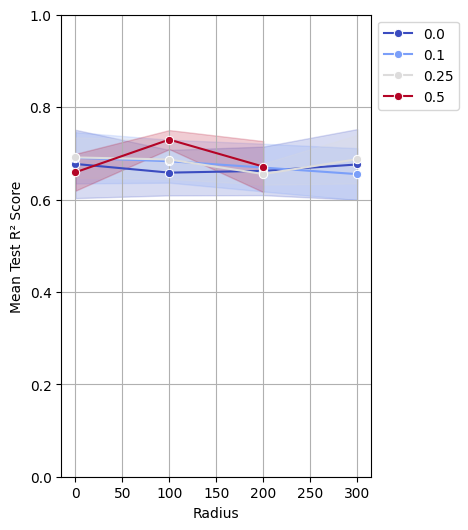

In [80]:
plot_robustness(df_gnntrans)

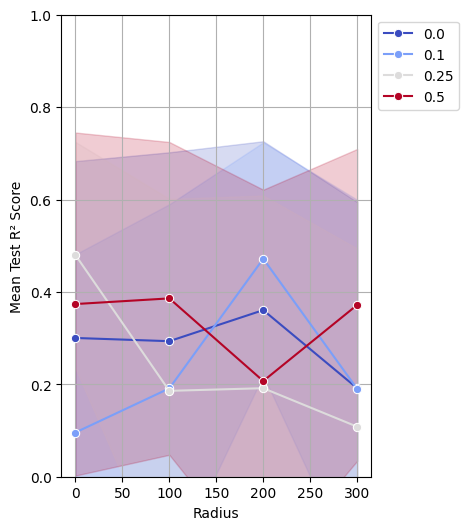

In [81]:
plot_robustness(df_gnn)